# Logistic Regression + Feature Scaling


## E-Commerce Customer Churn Prediction

Logistic Regression and Feature Scaling

Project Overview

Customer churn is an important challenge for e-commerce businesses because losing existing customers can directly affect customer retention and long-term revenue.

In this analysis, I use customer demographic, purchasing, and engagement data to investigate whether customer behavior can help predict churn.

Research Question

Can customer behavior and engagement data be used to predict whether an e-commerce customer will churn?

The target variable is Churned, where:

* 0 = Customer did not churn
* 1 = Customer churned

Objectives

The main objectives of this analysis are to:

* Explore and prepare the customer data for classification.
* Apply appropriate feature scaling to numerical variables.
* Build a Logistic Regression model to predict customer churn.
* Evaluate the model using appropriate classification metrics.
* Interpret the results to understand which customer characteristics are associated with churn.

Analysis Approach

The analysis will follow a practical machine learning workflow:

Data Inspection → Data Preparation → Feature Scaling → Logistic Regression → Model Evaluation → Interpretation

The goal is not only to build a predictive model, but also to understand what the model can tell us about customer churn behavior.

### 1. Data Loading and Initial Setup

The first step is to load the required Python libraries and import the e-commerce customer dataset.

At this stage, the focus is simply to load the data successfully and take an initial look at its structure before performing any preprocessing or modeling.

In [1]:
# Step 1 : Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce_customer_churn_dataset_dataset4 (1).xls")
df.head().T

,0,1,2,3,4
Age,43.0,36.0,45.0,56.0,35.0
Gender,Male,Male,Female,Female,Male
Country,France,UK,Canada,USA,India
City,Marseille,Manchester,Vancouver,New York,Delhi
Membership_Years,2.9,1.6,2.9,2.6,3.1
Login_Frequency,14.0,15.0,10.0,10.0,29.0
Session_Duration_Avg,27.4,42.7,24.8,38.4,51.4
Pages_Per_Session,6.0,10.3,1.6,14.8,NaN
Cart_Abandonment_Rate,50.6,37.7,70.9,41.7,19.1
Wishlist_Items,3.0,1.0,1.0,9.0,9.0


### 2. Initial Data Inspection

Before preparing the data for Logistic Regression, it is important to understand the overall structure and quality of the dataset.

In this section, I examine:

* The number of observations and features
* Data types of the variables
* Missing values
* Duplicate observations

This initial inspection helps identify any data quality issues that should be addressed before building the classification model.

In [3]:
# Dataset dimensions
print("Dataset shape:", df.shape)

# Data types and non_null values
df.info()

Dataset shape: (50000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Pur

Initial Findings

The dataset contains 50,000 customer observations and 25 variables.

Most variables are numerical, with 20 float variables and one integer variable, while four variables (Gender, Country, City, and Signup_Quarter) are categorical.

The target variable, Churned, contains no missing values, which is important for the classification task.

The initial inspection also shows that several numerical features contain missing values. Therefore, missing data will need to be examined and handled appropriately before training the Logistic Regression model.

### Missing Value Analysis

Missing values can affect model training and may reduce the amount of usable data if observations are simply removed.

Before choosing a strategy for handling missing data, I examine both the number and percentage of missing values in each feature.

In [4]:
# Count and percentage of missing values
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

# Show only columns containing missing values
missing_values[missing_values["Missing_Count"] > 0].sort_values(
    by="Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
Social_Media_Engagement_Score,6000,12.00
Credit_Balance,5500,11.00
Mobile_App_Usage,5000,10.00
Returns_Rate,4491,8.98
Wishlist_Items,4000,8.00
Discount_Usage_Rate,3500,7.00
Product_Reviews_Written,3500,7.00
Session_Duration_Avg,3399,6.80
Pages_Per_Session,3000,6.00
Days_Since_Last_Purchase,3000,6.00


### Missing Value Findings

Missing values are present across several numerical features, ranging from 0.34% to 12% of the observations. The highest missingness occurs in Social_Media_Engagement_Score (12%), Credit_Balance (11%), and Mobile_App_Usage (10%).

Because missing values are distributed across multiple features, removing every observation containing a missing value could unnecessarily reduce the available data.

Therefore, numerical missing values will be handled using median imputation during preprocessing. The median is preferred because it is less sensitive to extreme values and skewed distributions than the mean.

To avoid data leakage, imputation parameters will be learned from the training data rather than from the complete dataset.

### Duplicate Records and Target Distribution

Before preprocessing the features, I check for duplicate observations and examine the distribution of the target variable.

Understanding the class distribution of Churned is especially important because a highly imbalanced target can affect both model training and the interpretation of evaluation metrics.

In [5]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Target class counts
print("\nChurn counts:")
print(df["Churned"].value_counts())

# Target class percentages
print("\nChurn percentages:")
print((df["Churned"].value_counts(normalize=True) * 100).round(2))

Duplicate rows: 0

Churn counts:
Churned
0    35550
1    14450
Name: count, dtype: int64

Churn percentages:
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


### Duplicate and Target Distribution Findings

No duplicate observations were identified in the dataset.

The target variable shows a moderate class imbalance:

* 71.1% of customers did not churn (Churned = 0)
* 28.9% of customers churned (Churned = 1)

Although the imbalance is not extreme, accuracy alone may not provide a complete picture of model performance. Therefore, the Logistic Regression model will also be evaluated using precision, recall, F1-score, and a confusion matrix, with particular attention to the model’s ability to identify customers who churn.

In [6]:
# Number of unique values in categorical features
categorical_columns = ["Gender", "Country", "City", "Signup_Quarter"]

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Gender: 3 unique values
Country: 8 unique values
City: 40 unique values
Signup_Quarter: 4 unique values


### Categorical Feature Inspection

The dataset contains four categorical variables. Before encoding them for Logistic Regression, I examine their categories and cardinality to determine an appropriate preprocessing strategy.

Variables with a small number of categories can be efficiently represented using one-hot encoding, while higher-cardinality variables require additional consideration to avoid adding unnecessary model complexity.

In [7]:
# Inspect categorical values
for col in ["Gender", "Country", "Signup_Quarter"]:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Examine the relationship between Country and City
print("\nCities by Country:")
print(pd.crosstab(df["Country"], df["City"]))


Gender:
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

Country:
Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64

Signup_Quarter:
Signup_Quarter
Q3    12558
Q2    12521
Q4    12468
Q1    12453
Name: count, dtype: int64

Cities by Country:
City       Adelaide  Bangalore  Berlin  Birmingham  Brisbane  Calgary  \
Country                                                                 
Australia       817          0       0           0       794        0   
Canada            0          0       0           0         0     1204   
France            0          0       0           0         0        0   
Germany           0          0    1013           0         0        0   
India             0        698       0           0         0        0   
Japan             0          0       0           0         0        0   
UK  

### Categorical Feature Decision

The categorical variables contain relatively few categories, with the exception of City, which contains 40 unique values.

The city-level information is also nested within Country, meaning that the two variables represent overlapping geographic information at different levels of detail.

To keep the Logistic Regression model more interpretable and avoid creating a large number of additional dummy variables, City will be excluded from the primary model, while Country will be retained as the geographic feature.

The remaining categorical variables (Gender, Country, and Signup_Quarter) will be converted to numerical representations using one-hot encoding during preprocessing.

### 3. Feature and Target Definition

The dataset is now separated into predictor features (X) and the target variable (y).

The target variable is Churned, while the remaining customer characteristics are used as predictors. City is excluded based on the categorical feature assessment above.

In [8]:
# Define features and target
X = df.drop(columns=["Churned", "City"])
y = df["Churned"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (50000, 23)
Target shape: (50000,)


### 4. Train-Test Split

To evaluate how well the model generalizes to unseen customers, the dataset is divided into separate training and testing sets.

* 80% of the observations are used to train the model.
* 20% are reserved for final model evaluation.

Because the target variable is moderately imbalanced, stratified sampling is used to preserve approximately the same churn distribution in both the training and testing sets.

A fixed random state is also used to make the split reproducible.

In [9]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train shape: (40000, 23)
X_test shape: (10000, 23)

Training target distribution:
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64

Testing target distribution:
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


### 5. Feature Scaling and Preprocessing

The numerical features in this dataset are measured on very different scales. For example, variables such as Payment_Method_Diversity, Age, and Credit_Balance can have substantially different numerical ranges.

To place numerical features on a comparable scale, StandardScaler is applied:

[
z = \frac{x-\mu}{\sigma}
]

where:

* (x) is the original value
* (\mu) is the mean of the feature
* (\sigma) is the standard deviation of the feature

After standardization, numerical features are centered around zero with a standard deviation close to one.

Preprocessing Strategy

Different preprocessing steps are required for numerical and categorical features:

Numerical features

1. Missing values are replaced using median imputation.
2. Features are standardized using StandardScaler.

Categorical features

1. Gender, Country, and Signup_Quarter are converted into numerical features using one-hot encoding.

All preprocessing transformations are learned from the training data only and then applied to the test data. This prevents information from the test set from leaking into the model training process.

In [10]:
# Define numerical and categorical features
categorical_features = ["Gender", "Country", "Signup_Quarter"]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 20
Number of categorical features: 3

Numerical features:
['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']

Categorical features:
['Gender', 'Country', 'Signup_Quarter']


### Building the Preprocessing Pipeline

To ensure consistent preprocessing, separate transformations are defined for numerical and categorical variables.

For numerical features, missing values are first replaced with the training-set median and the resulting values are standardized. Categorical variables are transformed using one-hot encoding.

These transformations are combined using a ColumnTransformer, allowing the appropriate preprocessing steps to be applied automatically to each type of feature.

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Numerical preprocessing:
# 1. Replace missing values with the median
# 2. Standardize numerical features
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# Convert categories into binary indicator columns
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the appropriate preprocessing to each feature type
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

### Inspecting the Effect of Feature Scaling

To better understand standardization, a few numerical features are examined before and after applying median imputation and StandardScaler.

This comparison illustrates how features with very different original units and ranges are transformed to a common standardized scale while preserving their relative information.

In [12]:
# Fit numerical preprocessing using training data only
X_train_num_scaled = numerical_pipeline.fit_transform(
    X_train[numerical_features]
)

# Convert the transformed data to a DataFrame for inspection
X_train_num_scaled_df = pd.DataFrame(
    X_train_num_scaled,
    columns=numerical_features,
    index=X_train.index
)

# Compare selected features before and after scaling
comparison = pd.DataFrame({
    "Age_Original": X_train["Age"],
    "Age_Scaled": X_train_num_scaled_df["Age"],
    "Credit_Balance_Original": X_train["Credit_Balance"],
    "Credit_Balance_Scaled": X_train_num_scaled_df["Credit_Balance"]
})

comparison.head()

,Age_Original,Age_Scaled,Credit_Balance_Original,Credit_Balance_Scaled
48395,24.0,-1.196640,2187.0,0.195134
43060,49.0,0.968171,3173.0,1.046494
22404,56.0,1.574318,2582.0,0.536196
8602,69.0,2.700019,3789.0,1.578377
31036,47.0,0.794986,1540.0,-0.363516


### Feature Scaling Interpretation

The comparison demonstrates how standardization transforms variables with very different original scales into comparable standardized values.

For example, an age of 24 is transformed to approximately -1.20, indicating that it is below the mean age of the training data, while an age of 69 receives a standardized value of approximately 2.70, indicating that it is well above the training-set mean.

Similarly, Credit_Balance values originally measured in the thousands are transformed to a comparable standardized scale.

Importantly, standardization changes the scale of the variables but preserves their relative ordering and information. This allows numerical features with different units and ranges to be used together more consistently in the Logistic Regression model.

### 6. Logistic Regression Model

Logistic Regression is used to model the probability of a binary outcome. In this analysis, the outcome represents whether a customer churns (1) or does not churn (0).

The model estimates the probability of churn using the customer features and converts that probability into a class prediction. By default, a probability threshold of 0.50 is used:

* Probability < 0.50 → Predicted as No Churn (0)
* Probability ≥ 0.50 → Predicted as Churn (1)

The preprocessing steps and Logistic Regression model are combined into a single pipeline. This ensures that imputation, feature scaling, and categorical encoding are performed consistently and are learned only from the training data.

In [13]:
from sklearn.linear_model import LogisticRegression

# Create the complete modeling pipeline
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
# Generate predictions for unseen test data
y_pred = logistic_model.predict(X_test)

# Generate churn probabilities
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 predicted churn probabilities:")
print(y_prob[:10].round(3))

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 1]

First 10 predicted churn probabilities:
[0.032 0.118 0.293 0.146 0.014 0.048 0.068 0.016 0.054 0.815]


### 7. Model Evaluation

The Logistic Regression model is evaluated on the unseen test set to determine how well it generalizes to new customers.

Because the target variable is moderately imbalanced, model performance is evaluated using multiple classification metrics rather than accuracy alone:

* Accuracy: Overall proportion of correct predictions
* Precision: Among customers predicted to churn, the proportion who actually churned
* Recall: Among customers who actually churned, the proportion correctly identified by the model
* F1-score: A balance between precision and recall
* Confusion Matrix: A detailed comparison of actual and predicted classes

For customer churn prediction, recall for the churn class (1) is particularly informative because it measures how many actual churners the model successfully identifies.

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:  0.775
Precision: 0.677
Recall:    0.422
F1-score:  0.520

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      7110
           1       0.68      0.42      0.52      2890

    accuracy                           0.77     10000
   macro avg       0.74      0.67      0.69     10000
weighted avg       0.76      0.77      0.76     10000



### Model Performance Interpretation

The Logistic Regression model achieved an overall accuracy of 77.5%, which is higher than the 71.1% majority-class baseline.

However, the class-specific metrics reveal an important limitation. For customers who churned (Churned = 1), the model achieved:

* Precision: 67.7%
* Recall: 42.2%
* F1-score: 52.0%

The precision indicates that when the model predicts churn, the prediction is correct approximately two-thirds of the time. However, the recall of 42.2% shows that the model identifies fewer than half of the customers who actually churn.

In contrast, the model performs substantially better at identifying customers who do not churn, with a recall of approximately 92% for class 0.

Therefore, while the model improves upon the majority-class baseline and provides useful predictive information, its ability to detect actual churners is limited. For a customer-retention application, improving recall for the churn class would be an important area for further model development.

### Confusion Matrix

The confusion matrix provides a more detailed view of the model’s predictions by showing the number of correctly and incorrectly classified customers in each class.

This is particularly useful for identifying how many actual churners were successfully detected and how many were missed by the model.

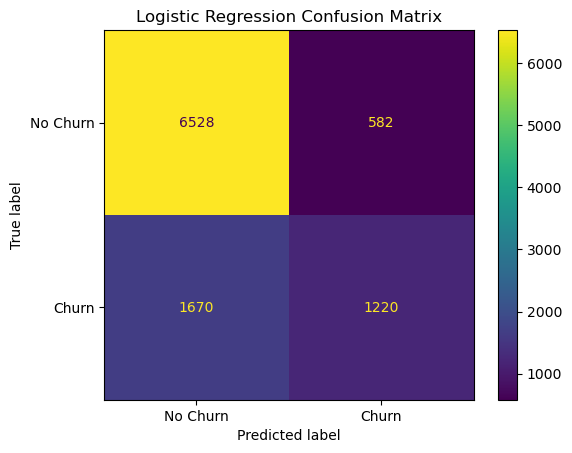

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix provides a clearer view of the model’s strengths and limitations:

* 6,528 True Negatives: Customers who did not churn and were correctly classified.
* 582 False Positives: Customers who did not churn but were incorrectly predicted to churn.
* 1,220 True Positives: Customers who churned and were correctly identified by the model.
* 1,670 False Negatives: Customers who churned but were incorrectly classified as non-churners.

The relatively large number of false negatives explains the churn-class recall of 42.2%. Of the 2,890 customers who actually churned in the test set, the model correctly identified 1,220 but missed 1,670.

From a customer-retention perspective, these false negatives are particularly important because they represent customers at risk of churn who would not be identified for potential intervention.

### 8. Logistic Regression Coefficient Analysis

One advantage of Logistic Regression is its interpretability. The coefficients learned by the model can be examined to understand which features are associated with higher or lower predicted odds of customer churn.

* A positive coefficient is associated with higher predicted odds of churn.
* A negative coefficient is associated with lower predicted odds of churn.
* A larger absolute coefficient indicates a stronger contribution to the model’s prediction, within the model’s feature representation.

Because the numerical variables were standardized before model training, their coefficients are more directly comparable than they would be on their original scales.

These coefficients describe associations within the predictive model and should not be interpreted as causal effects.

In [17]:
# Get feature names after preprocessing
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

# Create a DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient magnitude
coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

# Sort by coefficient magnitude
coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
18,num__Lifetime_Value,0.822969,0.822969
5,num__Cart_Abandonment_Rate,0.577959,0.577959
13,num__Customer_Service_Calls,0.574299,0.574299
9,num__Days_Since_Last_Purchase,0.391380,0.391380
0,num__Age,-0.297470,0.297470
7,num__Total_Purchases,-0.296000,0.296000
21,cat__Gender_Male,-0.281575,0.281575
20,cat__Gender_Female,-0.259358,0.259358
33,cat__Signup_Quarter_Q3,-0.225468,0.225468
11,num__Returns_Rate,0.212089,0.212089


### Coefficient Interpretation

The coefficient analysis highlights several features that contribute strongly to the Logistic Regression model.

Among the numerical features, Lifetime_Value has the largest positive coefficient (0.823), followed by Cart_Abandonment_Rate (0.578), Customer_Service_Calls (0.574), and Days_Since_Last_Purchase (0.391). Higher values of these features are therefore associated with higher predicted odds of churn, holding the other model features constant.

Several features show negative associations with churn. For example, Total_Purchases (-0.296), Discount_Usage_Rate (-0.210), and Email_Open_Rate (-0.200) are associated with lower predicted odds of churn.

The positive coefficient for Lifetime_Value is particularly noteworthy because it may initially appear counterintuitive. However, Logistic Regression coefficients represent conditional associations while accounting for the other variables in the model. Therefore, this result should be interpreted within the multivariable model rather than as a simple standalone relationship.

Overall, the results suggest that customer purchasing behavior, cart abandonment, service interactions, and recency of purchasing activity contain useful information for predicting churn. These relationships are predictive associations and should not be interpreted as causal effects.

### Most Influential Numerical Features

To make the Logistic Regression results easier to interpret, the numerical features with the largest absolute coefficients are visualized below.

The direction of each coefficient is preserved:

* Positive coefficients indicate an association with higher predicted odds of churn.
* Negative coefficients indicate an association with lower predicted odds of churn.

The visualization focuses on numerical features because they were standardized before model training, making their coefficient magnitudes more directly comparable.

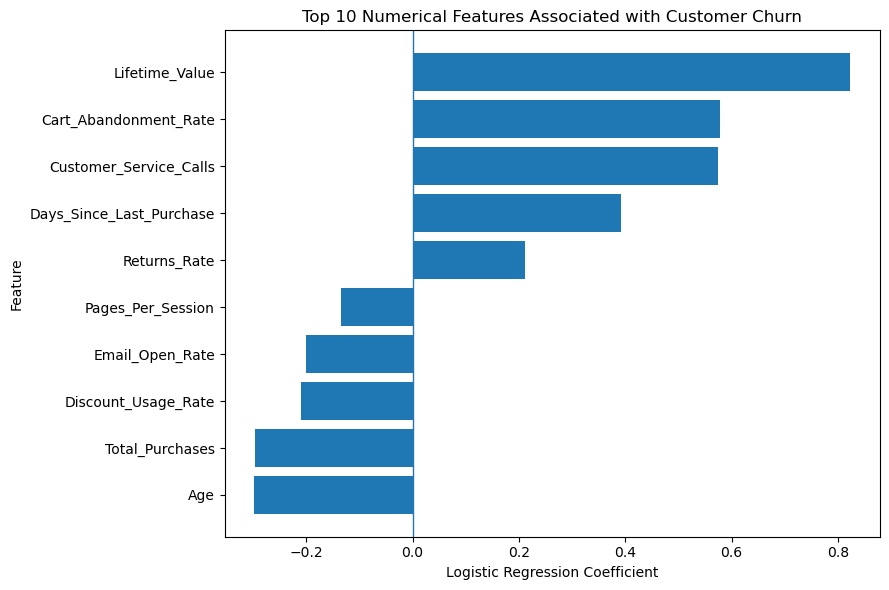

In [18]:
# Keep only numerical features
num_coef_df = coef_df[
    coef_df["Feature"].str.startswith("num__")
].copy()

# Clean feature names
num_coef_df["Feature"] = (
    num_coef_df["Feature"]
    .str.replace("num__", "", regex=False)
)

# Select the 10 strongest numerical coefficients
top10_num = (
    num_coef_df
    .nlargest(10, "Absolute_Coefficient")
    .sort_values("Coefficient")
)

# Plot
plt.figure(figsize=(9, 6))

plt.barh(
    top10_num["Feature"],
    top10_num["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Numerical Features Associated with Customer Churn")

plt.tight_layout()
plt.show()

### Feature Coefficient Visualization Interpretation

The coefficient visualization shows clear differences in the direction and magnitude of the numerical features associated with customer churn.

Lifetime_Value has the strongest positive coefficient, followed by Cart_Abandonment_Rate, Customer_Service_Calls, and Days_Since_Last_Purchase. These features are associated with higher predicted odds of churn in the fitted model.

In contrast, Age, Total_Purchases, Discount_Usage_Rate, Email_Open_Rate, and Pages_Per_Session show negative coefficients, indicating associations with lower predicted odds of churn.

These results provide insight into how the Logistic Regression model makes its predictions; however, the observed relationships represent predictive associations rather than causal effects.

# 9. Final Conclusion

This analysis used Logistic Regression to investigate whether customer behavior and engagement characteristics can be used to predict customer churn.

After preprocessing the data—including median imputation for missing numerical values, feature scaling, and one-hot encoding of categorical variables—the Logistic Regression model achieved an overall test accuracy of 77.5%, compared with a 71.1% majority-class baseline.

However, the class-specific results provide a more complete picture. For customers who actually churned, the model achieved 67.7% precision, 42.2% recall, and an F1-score of 52.0%. The confusion matrix showed that the model correctly identified 1,220 churners, but missed 1,670 actual churners. Therefore, although the model improves upon the baseline and provides meaningful predictive information, its ability to identify customers at risk of churn remains limited.

The coefficient analysis also revealed several notable predictive relationships. Lifetime_Value, Cart_Abandonment_Rate, Customer_Service_Calls, and Days_Since_Last_Purchase showed the strongest positive associations with predicted churn among the numerical features. In contrast, Age, Total_Purchases, Discount_Usage_Rate, and Email_Open_Rate were associated with lower predicted odds of churn.

Overall, Logistic Regression provides a useful and interpretable baseline model for this customer churn problem. The results suggest that purchasing behavior, customer-service interactions, and customer engagement contain meaningful information for churn prediction.

### Key Limitation and Next Step:

The primary limitation of the current model is its relatively low recall for churners. In a customer-retention setting, missing customers who are likely to churn may be more costly than incorrectly flagging some customers who ultimately remain.

Future analysis could therefore explore approaches such as adjusting the classification threshold, applying class weighting, or comparing Logistic Regression with alternative classification models to improve churn detection while carefully monitoring the trade-off between precision and recall.

The relationships identified in this analysis should be interpreted as predictive associations rather than causal effects.